# Notebook to get the height of aurora using fieldline method (see Whiter et al. (2010))

## Functions to relate (lat, lon, alt) and image pixels (can be replaced by using the StarCal files)

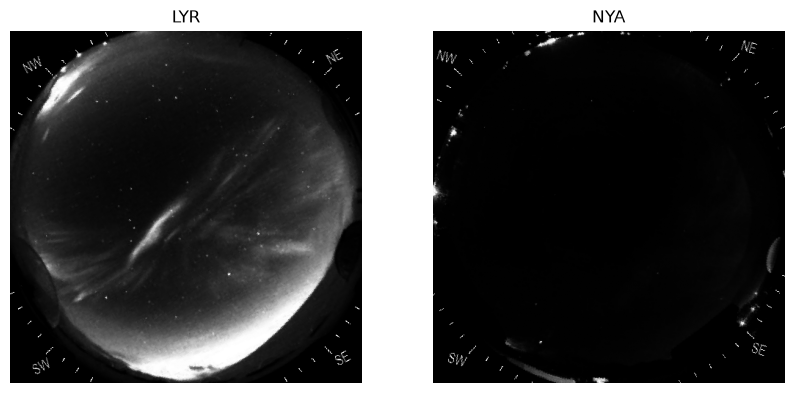

In [1]:
import os
from pathlib import Path
from datetime import datetime, timezone
from PIL import Image, ImageOps
import math
import matplotlib.pyplot as plt

event_dt = datetime(2020, 1, 3, 8, 57, 41, tzinfo=timezone.utc) #Time and date of the event
date_time = event_dt.strftime("%Y%m%d%H%M%S")
unixtime = int(event_dt.timestamp())

h1 = 0.0          # camera altitude in km; 0 is what the original used, the two cameras are assumed to be at the same altitude
rr = 6371.0

lat0_LYR = 78.147778 * math.radians(1)   # LYR
lon0_LYR = 16.039722 * math.radians(1)
lat0_NYA = 78.923611 * math.radians(1)   # NYA
lon0_NYA = 11.930278 * math.radians(1)

DATA = Path("Data")
save_dir = f"out/out_fiedline_Guillaume_{date_time}"
os.makedirs(save_dir, exist_ok=True)

def rotate_and_crop(image, rotation_center, rotation_angle, border, fill=0):
    """
    A function that rotates an image around a specified centre and crops a specific area.
    It exists so the simple equidistant model in inverse_mapping is valid.

    Parameters: image (PIL.
        image (PIL.Image)): The image to be processed
        rotation_centre (tuple): Coordinates of the rotation centre (x, y) = (column, row)
        rotation_angle (float): Rotation angle (in degrees)
        border (int): The size of the border to be added
        fill (int): The colour of the border (default: 0 = black)

    Return value: PIL.
        PIL.Image: The cropped image
    """
    # Expand an image with a given border
    expanded_image = ImageOps.expand(image, border, fill=fill)

    # Adjust the center of rotation to match the expanded image
    new_center = (rotation_center[0] + border, rotation_center[1] + border)

    # rotate the image at the specified center
    rotated_image = expanded_image.rotate(rotation_angle, center=new_center)

    # rage of trimming
    crop_box = (
        new_center[0] - border,
        new_center[1] - border,
        new_center[0] + border,
        new_center[1] + border
    )

    # trimming image
    cropped_image = rotated_image.crop(crop_box)

    return cropped_image


cropped_LYR = rotate_and_crop(Image.open(DATA / "BACC_LYR2020.png"),
                               rotation_center=(302, 286), rotation_angle=28.0, border=240)
cropped_NYA = rotate_and_crop(Image.open(DATA / "BACC_NYA2020.png"),
                               rotation_center=(312, 291), rotation_angle=-16.9, border=240)

# cropped_LYR = rotate_and_crop(Image.open(DATA / "greyscale_BACC_LYR_20200103_085741.png"),
#                                rotation_center=(302, 286), rotation_angle=28.0, border=240)
# cropped_NYA = rotate_and_crop(Image.open(DATA / "greyscale_BACC_NYA_20200103_085741.png"),
#                                rotation_center=(312, 291), rotation_angle=-16.9, border=240)

xsize, ysize = cropped_LYR.size  # 480, 480

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cropped_LYR, cmap="gray")
ax[0].set_title("LYR")
ax[0].axis("off")
ax[1].imshow(cropped_NYA, cmap="gray")
ax[1].set_title("NYA")
ax[1].axis("off")
plt.show()

## Function settings for the magnetic field line tracing method

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import PyGeopack as gp
from scipy.signal import medfilt

# Create date in YYYYYMMDD format
dates = int(event_dt.strftime("%Y%m%d"))
# Calculate UT (time) (decimal format: hours + minutes/60 + seconds/3600)
ut_time = event_dt.hour + event_dt.minute / 60 + event_dt.second / 3600

cropped_LYR_np = np.array(cropped_LYR, dtype=np.uint16)
cropped_NYA_np = np.array(cropped_NYA, dtype=np.uint16)


def field_line_tracing(lat_fl, lon_fl, alt_fl, upper, lower, interval):
    """
    A version that uses `alt_fl` as the central altitude,
    where the actual starting point of the trace is at `(alt_fl + upper)`,
    and follows the magnetic field lines only downwards from that point.
    """

    lat_fieldline = []
    lon_fieldline = []
    alt_fieldline = []

    # Altitude range to be tracked (top to bottom)
    alt_top    = alt_fl + upper
    alt_bottom = alt_fl - lower
    alt_range  = np.arange(alt_top, alt_bottom - 1e-6, -interval)

    # The starting point is alt_top ( = alt_fl + upper)
    r_geo = (rr + alt_top) / rr   # given in Re (Earth radii)

    lat_rad = np.deg2rad(lat_fl)
    lon_rad = np.deg2rad(lon_fl)

    # (x, y, z) in GEO at alt_top
    x_geo = r_geo * np.cos(lat_rad) * np.cos(lon_rad)
    y_geo = r_geo * np.cos(lat_rad) * np.sin(lon_rad)
    z_geo = r_geo * np.sin(lat_rad)

    # GEO → GSM (The starting point remains the same throughout)
    x_gsm, y_gsm, z_gsm = gp.Coords.GEOtoGSM(x_geo, y_geo, z_geo, dates, ut_time)

    # From alt_top to alt_bottom, trace only downwards
    for alt in alt_range:
        trace = gp.TraceField(x_gsm, y_gsm, z_gsm,
                              dates, ut_time,
                              coord_In='GSM', alt=alt)

        lat_fieldline.append(trace.GlatN)
        lon_fieldline.append(trace.GlonN)
        alt_fieldline.append(alt)

    # If we reorder the altitudes here in ascending order (from ‘low’ to ‘high’),
    # the orientation will match that of the existing profile rendering
    lat_fieldline  = lat_fieldline[::-1]
    lon_fieldline  = lon_fieldline[::-1]
    alt_fieldline  = alt_fieldline[::-1]

    return lat_fieldline, lon_fieldline, alt_fieldline

def inverse_mapping(lat_fieldline, lon_fieldline, alt_fieldline, lat0, lon0, h1, rr=6371.0):
    """
    Function to find pixel coordinates on an image from latitude, longitude, and altitude.
    """
    lat_fieldline_rad = np.radians(lat_fieldline)
    lon_fieldline_rad = np.radians(lon_fieldline)

    x_points = []
    y_points = []

    for lat, lon, alt in zip(lat_fieldline_rad, lon_fieldline_rad, alt_fieldline):
        if isinstance(lat, np.ndarray):
            lat = lat.item()
        if isinstance(lon, np.ndarray):
            lon = lon.item()
        if isinstance(alt, np.ndarray):
            alt = alt.item()

        b = 0.5 * math.pi - lat
        c = 0.5 * math.pi - lat0
        aa = lon - lon0

        cosa = math.cos(b) * math.cos(c) + math.sin(b) * math.sin(c) * math.cos(aa)
        sina = math.sqrt(1.0 - cosa * cosa)

        if sina == 0:
            continue

        sinbb = math.sin(b) * math.sin(aa) / sina
        cosbb = (math.cos(b) * math.sin(c) - math.sin(b) * math.cos(c) * math.cos(aa)) / sina

        the = math.atan2((rr + alt) * sina, (rr + alt) * cosa - (rr + h1))
        l0 = 0.5 * ysize * the / (0.5 * math.pi)

        x = 0.5 * xsize + l0 * sinbb #  x = 0.5 * xsize - l0 * sinbb for East Left (ASC image)
        y = 0.5 * ysize - l0 * cosbb

        i = int(round(y))
        j = int(round(x))

        if 0 <= i < ysize and 0 <= j < xsize:
            y_points.append(i)
            x_points.append(j)

    return x_points, y_points

The $GEOPACK_PATH variable has not been set, this module will not function correctly without it
Data file does not exist - to create data file run "PyGeopack.Params.UpdateParameters()"
Loading Model Parameter File:



In [3]:
def brightness_vs_altitude(x_points_LYR, y_points_LYR, x_points_NYA, y_points_NYA, alt_fieldline):
    brightness_LYR = []
    brightness_NYA = []

    for x, y in zip(x_points_LYR, y_points_LYR):
        if 0 <= y < cropped_LYR_np.shape[0] and 0 <= x < cropped_LYR_np.shape[1]:
            brightness_LYR.append(cropped_LYR_np[int(y), int(x)])
        else:
            brightness_LYR.append(np.nan)

    for x, y in zip(x_points_NYA, y_points_NYA):
        if 0 <= y < cropped_NYA_np.shape[0] and 0 <= x < cropped_NYA_np.shape[1]:
            brightness_NYA.append(cropped_NYA_np[int(y), int(x)])
        else:
            brightness_NYA.append(np.nan)

    brightness_LYR = np.array(brightness_LYR)
    brightness_NYA = np.array(brightness_NYA)
    alt_fieldline = np.array(alt_fieldline)

    return brightness_LYR, brightness_NYA, alt_fieldline

In [4]:
def fit_and_find_peak_med(altitudes, brightness):
    valid_idx = ~np.isnan(brightness)
    altitudes, brightness = altitudes[valid_idx], brightness[valid_idx]

    if len(altitudes) == 0:
        return None, None, None

    brightness_smooth = medfilt(brightness, kernel_size=3)

    peak_idx = np.argmax(brightness_smooth)
    peak_altitude = altitudes[peak_idx]
    peak_brightness = brightness_smooth[peak_idx]

    return altitudes, brightness_smooth, (peak_altitude, peak_brightness)

def fit_and_find_peak(altitudes, brightness):
    valid_idx = ~np.isnan(brightness)  # Remove NaN values
    altitudes, brightness = altitudes[valid_idx], brightness[valid_idx]

    if len(altitudes) < 4:  # Not enough data for cubic fitting
        return None, None, None

    poly_coeffs = np.polyfit(altitudes, brightness, 3)  # Cubic fit
    poly_func = np.poly1d(poly_coeffs)  # Create polynomial function

    # Generate smooth curve for plotting
    alt_smooth = np.linspace(min(altitudes), max(altitudes), 100)
    brightness_smooth = poly_func(alt_smooth)

    # Find peak (maximum value of the fitted curve)
    peak_idx = np.argmax(brightness_smooth)
    peak_altitude = alt_smooth[peak_idx]
    peak_brightness = brightness_smooth[peak_idx]

    return poly_func, peak_altitude, peak_brightness

def calculation_for_conditions(brightness_LYR, brightness_NYA, alt_fieldline):
    """
    Parameters:
        brightness_LYR (list): list of brightness values for LYR.
        brightness_NYA (list): list of brightness values for NYA.
        alt_fieldline (list): list of altitudes for each point.

    Returns:
        dict: Dictionary containing correlation, peak altitude, peak brightness, centre, percentile ratio,
              mean brightness above peak altitude, mean brightness below peak altitude for both graphs.
    """
    # Remove NaN values for correlation computation
    valid_indices = ~np.isnan(brightness_LYR) & ~np.isnan(brightness_NYA)
    correlation = np.corrcoef(brightness_LYR[valid_indices], brightness_NYA[valid_indices])[0, 1]

    poly_func_LYR, peak_alt_LYR, peak_brightness_LYR = fit_and_find_peak(alt_fieldline, brightness_LYR)
    poly_func_NYA, peak_alt_NYA, peak_brightness_NYA = fit_and_find_peak(alt_fieldline, brightness_NYA)

    # Compute Centre (Σ(brightness_values * altitude) / Σbrightness_values)
    def compute_centre(altitudes, brightness_values):
        valid_idx = ~np.isnan(brightness_values)
        altitudes, brightness_values = altitudes[valid_idx], brightness_values[valid_idx]
        return np.sum(brightness_values * altitudes) / np.sum(brightness_values) if np.sum(brightness_values) != 0 else np.nan

    centre_LYR = compute_centre(alt_fieldline, brightness_LYR)
    centre_NYA = compute_centre(alt_fieldline, brightness_NYA)

    # Compute P (60% percentile / median)
    def compute_p(brightness_values):
        valid_values = brightness_values[~np.isnan(brightness_values)]
        if len(valid_values) == 0:
            return np.nan
        percentile_60 = np.percentile(valid_values, 60)
        median_brightness = np.median(valid_values)
        return percentile_60 / median_brightness if median_brightness != 0 else np.nan

    percentile_LYR = compute_p(brightness_LYR)
    percentile_NYA = compute_p(brightness_NYA)

    # Compute mean brightness above and below peak altitude
    def mean_above_below_peak(altitudes, brightness_values, peak_altitude):
        valid_idx = ~np.isnan(brightness_values)
        altitudes, brightness_values = altitudes[valid_idx], brightness_values[valid_idx]

        above = brightness_values[altitudes > peak_altitude]
        below = brightness_values[altitudes < peak_altitude]

        mean_above = np.mean(above) if len(above) > 0 else np.nan
        mean_below = np.mean(below) if len(below) > 0 else np.nan

        return mean_above, mean_below

    mean_above_LYR, mean_below_LYR = mean_above_below_peak(alt_fieldline, brightness_LYR, peak_alt_LYR)
    mean_above_NYA, mean_below_NYA = mean_above_below_peak(alt_fieldline, brightness_NYA, peak_alt_NYA)

    return correlation, peak_alt_LYR, peak_brightness_LYR, centre_LYR, percentile_LYR, mean_above_LYR, mean_below_LYR, peak_alt_NYA, peak_brightness_NYA, centre_NYA, percentile_NYA, mean_above_NYA, mean_below_NYA

def compute_peak_width(altitudes, brightness_values, frac):
    """
    altitudes: altitude array (ascending, km)
    brightness_values: intensity along the field line (same length, NaNs allowed)
    frac: frac=0.9 means the width is measured where brightness is still ≥ 90% of the peak

    Returns:
        width_km : width [km] (high − low)
        low_alt  : altitude where intensity drops below the threshold (below the peak)
        high_alt : altitude where intensity drops below the threshold (above the peak)
    """
    altitudes = np.asarray(altitudes)
    brightness_values = np.asarray(brightness_values)

    valid = np.isfinite(brightness_values)
    if valid.sum() < 3:
        return np.inf, np.nan, np.nan

    alts = altitudes[valid]
    vals = brightness_values[valid]

    # Smooth it out a little (same as in `fit_and_find_peak_med`)
    smooth = medfilt(vals, kernel_size=3)

    # Find the peak
    peak_idx = np.argmax(smooth)
    peak_alt = alts[peak_idx]
    peak_val = smooth[peak_idx]
    if peak_val <= 0:
        return np.inf, np.nan, np.nan

    threshold = peak_val * frac

    # Trace downwards
    i_low = peak_idx
    while i_low > 0 and smooth[i_low] >= threshold:
        i_low -= 1
    low_alt = alts[i_low]

    # Trace upwards
    i_high = peak_idx
    n = len(alts) - 1
    while i_high < n and smooth[i_high] >= threshold:
        i_high += 1
    high_alt = alts[i_high]

    width_km = high_alt - low_alt
    return width_km, low_alt, high_alt



## Trace fieldlines

In [5]:
def trace_and_filter_field_lines(
    lat_range, lon_range, alt_fl,
    step, upper, lower, interval,
    peak, corr_thr, edge, frac, width_limit, median_thr
):
    """
    Traces field lines for a given (lat_range, lon_range) and
    returns information on the field lines that satisfy the conditions.
    """

    lat_fl_values = np.arange(*lat_range, step)
    lon_fl_values = np.arange(*lon_range, step)

    # Store the profiles and coordinates of lines that meet the criteria
    all_brightness_values_LYR = []
    all_brightness_values_NYA = []
    lines_LYR = []
    lines_NYA = []

    alt_fieldline_last = None
    sample_size = 0

    for lat_fl in lat_fl_values:
        for lon_fl in lon_fl_values:
            # Field-line tracing (from top to bottom, td = top-down)
            lat_td, lon_td, alt_td = field_line_tracing(
                lat_fl, lon_fl, alt_fl, upper, lower, interval
            )

            x1_td, y1_td = inverse_mapping(
                lat_td, lon_td, alt_td,
                lat0_LYR, lon0_LYR, h1
            )
            x2_td, y2_td = inverse_mapping(
                lat_td, lon_td, alt_td,
                lat0_NYA,  lon0_NYA,  h1
            )

            brightness_LYR_td, brightness_NYA_td, alt_td = brightness_vs_altitude(
                x1_td, y1_td, x2_td, y2_td, alt_td
            )

            # Calculate profile features, etc.
            corr_td, palt1_td, pray1_td, cen1_td, p1_td, ma1_td, mb1_td, \
                palt2_td, pray2_td, cen2_td, p2_td, ma2_td, mb2_td = \
                calculation_for_conditions(brightness_LYR_td, brightness_NYA_td, alt_td)

            # Calculate width at 90% of peak
            width90_augo1_td, low90_augo1_td, high90_augo1_td = \
                compute_peak_width(alt_td, brightness_LYR_td, frac=frac)
            width90_augso_td, low90_augso_td, high90_augso_td = \
                compute_peak_width(alt_td, brightness_NYA_td, frac=frac)

            # Selection Criteria
            cond = (
                abs(palt1_td - palt2_td) < peak and
                alt_fl - lower + edge < palt1_td < alt_fl + upper - edge and
                alt_fl - lower + edge < palt2_td < alt_fl + upper - edge and
                abs(cen1_td - cen2_td) < median_thr and
                corr_td > corr_thr and
                (pray1_td > ma1_td * p1_td or pray1_td > mb1_td * p1_td) and
                (pray2_td > ma2_td * p2_td or pray2_td > mb2_td * p2_td) and
                width90_augo1_td <= width_limit and
                width90_augso_td <= width_limit
            )

            if cond:
                all_brightness_values_LYR.append(np.array(brightness_LYR_td))
                all_brightness_values_NYA.append(np.array(brightness_NYA_td))

                lines_LYR.append(
                    (np.asarray(x1_td).ravel(), np.asarray(y1_td).ravel())
                )
                lines_NYA.append(
                    (np.asarray(x2_td).ravel(), np.asarray(y2_td).ravel())
                )

                alt_fieldline_last = np.array(alt_td)
                sample_size += 1

    if sample_size == 0 or alt_fieldline_last is None:
        print(f"[{lat_range}, {lon_range}] No valid field lines.")
        return [], [], np.array([]), [], []

    return all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA

Build altitude profiles with the field-line tracing method
for one or more latitude/longitude boxes.

Example regions:
regions = [
    {'lat1':52, 'lat2':54, 'lon1':-111, 'lon2':-109, 'label':'R1'},
    {'lat1':53, 'lat2':54, 'lon1':-112.5, 'lon2':-111, 'label':'R2'},
    {'lat1':54, 'lat2':55, 'lon1':-112.5, 'lon2':-111, 'label':'R3'}
]

Altitude window: 55–150 km every 2 km
(reference alt_fl=100, upper=50 km, lower=45 km, interval=2 km)

Field-line acceptance tests:
- Peak altitudes at the two sites differ by < 5 km          peak=5
- Profile correlation ≥ 0.8                                 corr_thr=0.8
- Neither peak within 10 km of the top or bottom of the window  edge=10
- Peaks are well defined; 90% width ≤ 40 km                 frac=0.9, width_limit=40
- Intensity-weighted centroids differ by < 20 km            median_thr=20

region_data = trace_and_filter_field_lines(
    regions, colors,
    alt_fl=100, step=0.1,
    upper=50, lower=45, interval=2,
    peak=5, corr_thr=0.8, edge=10, width_limit=40,
    save_prefix=date_time
)

In [96]:
region = [
    {'lat1': 77.2, 'lat2': 78.2, 'lon1': 12.0, 'lon2': 15., 'label': 'R1'},
]

for reg in region:
    lat_range = (reg['lat1'], reg['lat2'])
    lon_range = (reg['lon1'], reg['lon2'])


all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA =trace_and_filter_field_lines(
    lat_range, lon_range,
    alt_fl=165, step=0.1,
    upper=85, lower=85, interval=2,
    peak=15, corr_thr=0.5, edge=0, frac=0.9, width_limit=999, median_thr=20,
)

## Plot fieldlines and brightness profiles

In [115]:
def make_plots(all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA, lat_range, lon_range, save_prefix=None):
    
    label_str = f"lat={lat_range[0]}–{lat_range[1]}, lon={lon_range[0]}–{lon_range[1]}"

    fig_im, (ax_im1, ax_im2) = plt.subplots(1, 2, figsize=(12, 6))

    flipped_LYR = cropped_LYR_np
    flipped_NYA = cropped_NYA_np
    ax_im1.imshow(flipped_LYR, cmap='gray')
    ax_im2.imshow(flipped_NYA, cmap='gray')
    ax_im1.set_title(f"LYR: {label_str}")
    ax_im2.set_title(f"NYA: {label_str}")

    colors_cycle = [
        "#ff0000","#ff4000","#ff8000","#ffbf00","#ffff00",
        "#bfff00","#80ff00","#40ff00","#00ff80","#00ffbf",
        "#00ffff","#00bfff","#0080ff","#0040ff","#0000ff"
    ]
    line_colors = []   # ← CHANGED: 各ラインの色を記録

    for idx, ((x1, y1), (x2, y2)) in enumerate(zip(lines_LYR, lines_NYA)):
        c = colors_cycle[idx % len(colors_cycle)]
        line_colors.append(c)   # ← CHANGED
        ax_im1.scatter(x1, y1, c=c, s=2,
                        label=f"line {idx+1}" if idx < len(colors_cycle) else None)
        ax_im2.scatter(x2, y2, c=c, s=2,
                        label=f"line {idx+1}" if idx < len(colors_cycle) else None)

    # 凡例（重複除去）
    def uniq_legend(ax):
        h, l = ax.get_legend_handles_labels()
        if not h:
            return
        uniq = dict(zip(l, h))
        ax.legend(uniq.values(), uniq.keys(),
                    loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8)

    uniq_legend(ax_im1)
    uniq_legend(ax_im2)

    plt.tight_layout()
    if save_prefix is not None:
        path_im = os.path.join(save_dir, f"{save_prefix}_fieldlines.png")
        plt.savefig(path_im, bbox_inches="tight")
        print(f"Saved: {path_im}")
    plt.show()

    # Brightness-Altitude profiles
    arr1 = np.vstack(all_brightness_values_LYR)  # (n_line, n_alt)
    arr2 = np.vstack(all_brightness_values_NYA)

    mean1 = np.nanmean(arr1, axis=0)
    mean2 = np.nanmean(arr2, axis=0)

    mean1_s = medfilt(mean1, kernel_size=3)
    mean2_s = medfilt(mean2, kernel_size=3)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    alt = alt_fieldline_last

    # ------------------------------------------------------------
    # ★ Peak detection（Find the peak of the average profile）
    # ------------------------------------------------------------
    idx_pk1 = np.nanargmax(mean1)    # ←★追加
    pk_ray1 = mean1_s[idx_pk1]         # ←★追加
    pk_alt1 = alt[idx_pk1]             # ←★追加

    idx_pk2 = np.nanargmax(mean2)    # ←★追加
    pk_ray2 = mean2_s[idx_pk2]         # ←★追加
    pk_alt2 = alt[idx_pk2]             # ←★追加

    print(f"{label_str} LYR:{pk_alt1}, NYA:{pk_alt2}")

    def peak_altitudes(profiles, alt):
        peaks = []
        for p in profiles:
            p = np.asarray(p, dtype=float)
            if not np.any(np.isfinite(p)):
                continue
            peaks.append(float(alt[int(np.nanargmax(p))]))
        return np.asarray(peaks)

    peaks_lyr = peak_altitudes(all_brightness_values_LYR, alt)
    peaks_nya = peak_altitudes(all_brightness_values_NYA, alt)
    peaks_all = np.concatenate([peaks_lyr, peaks_nya])
    
    def stats(peaks):
        mu = np.nanmean(peaks)
        sig = np.nanstd(peaks, ddof=1)
        sem = sig / np.sqrt(len(peaks))
        return mu, sig, sem

    mu1, sig1, sem1 = stats(peaks_lyr)
    mu2, sig2, sem2 = stats(peaks_nya)
    mu, sig, sem = stats(peaks_all)
    
    print(f"LYR  {mu1:.1f} ± {sig1:.1f} km (std),  SEM {sem1:.1f} km")
    print(f"NYA  {mu2:.1f} ± {sig2:.1f} km (std),  SEM {sem2:.1f} km")
    print(f"Both {mu:.1f} ± {sig:.1f} km (std),  SEM {sem:.1f} km")

    # LYR
    for prof, c in zip(all_brightness_values_LYR, line_colors):
        ax1.plot(prof, alt, color=c, alpha=0.8, lw=1.2)
    # Average (smoothed) shown in thick black line
    ax1.plot(mean1_s, alt, color='black', lw=2.5, label='Mean (smoothed)')
    ax1.axhline(pk_alt1, ls="--", color="k", lw=1, label=f"Peak {pk_alt1:.0f} km")
    ax1.set_xlabel("Brightness (pixel value)")
    ax1.set_ylabel("Altitude (km)")
    ax1.set_title(f"LYR {label_str}")
    ax1.grid(True)
    ax1.legend(loc='best')

    # NYA
    for prof, c in zip(all_brightness_values_NYA, line_colors):
        ax2.plot(prof, alt, color=c, alpha=0.8, lw=1.2)
    ax2.plot(mean2_s, alt, color='black', lw=2.5, label='Mean (smoothed)')
    ax2.axhline(pk_alt2, ls="--", color="k", lw=1, label=f"Peak {pk_alt2:.0f} km")
    ax2.set_xlabel("Brightness (pixel value)")
    ax2.set_title(f"NYA {label_str}")
    ax2.grid(True)
    ax2.legend(loc='best')

    plt.tight_layout()
    if save_prefix is not None:
        path_prof = os.path.join(save_dir, f"{save_prefix}_profiles_single.png")
        plt.savefig(path_prof, bbox_inches="tight")
        print(f"Saved: {path_prof}")
    plt.show()


    # ------------------------------------------------------------
    # Plot normalised brightness profiles (mean of both)
    # ------------------------------------------------------------
    arrLYR = np.vstack(all_brightness_values_LYR)  # (n_line, n_alt)
    arrNYA = np.vstack(all_brightness_values_NYA)

    maxLYR = np.nanmax(arrLYR)
    maxNYA = np.nanmax(arrNYA)

    normLYR = arrLYR / maxLYR
    normNYA = arrNYA / maxNYA

    mean_normLYR = np.nanmean(normLYR, axis=0)
    std_normLYR = np.nanstd(normLYR, axis=0)
    mean_normNYA = np.nanmean(normNYA, axis=0)
    std_normNYA = np.nanstd(normNYA, axis=0)
    mean_norm_both = np.nanmean(np.vstack([normLYR, normNYA]), axis=0)
    std_norm_both = np.nanstd(np.vstack([normLYR, normNYA]), axis=0)

    pk_lyr_idx = int(np.nanargmax(mean_normLYR))
    pk_nya_idx = int(np.nanargmax(mean_normNYA))
    pk_lyr_alt = float(alt[pk_lyr_idx])
    pk_nya_alt = float(alt[pk_nya_idx])
    pk_idx = int(np.nanargmax(mean_norm_both))
    pk_alt = float(alt[pk_idx])

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.plot(medfilt(mean_norm_both, kernel_size=3), alt, color='magenta', lw=3.5, label='Mean')
    ax.plot(mean_norm_both, alt, color='magenta', lw=1.)
    ax.fill_betweenx(alt, mean_norm_both - std_norm_both, mean_norm_both + std_norm_both,
                color="magenta", alpha=0.2, label="STD")

    ax.plot(mean_normLYR, alt, color='red', lw=1., label='Mean LYR')
    ax.plot(mean_normNYA, alt, color='blue', lw=1., label='Mean NYA')

    ax.axhline(pk_lyr_alt, ls="--", color="k", lw=1, label=f"Argmax LYR {pk_lyr_alt:.0f} km")
    ax.axhline(pk_nya_alt, ls="--", color="k", lw=1, label=f"Argmax NYA {pk_nya_alt:.0f} km")
    ax.axhline(pk_alt, ls="--", color="k", lw=2., label=f"Argmax Mean {pk_alt:.0f} km")

    ax.axhline(mu, color="k", lw=2, label=f"Mean of all peaks {mu:.0f}±{sem:.0f} km")
    
    for prof in normLYR:
        ax.plot(prof, alt, color='red', alpha=0.5, lw=1., ls='--')
    for prof in normNYA:
        ax.plot(prof, alt, color='blue', alpha=0.5, lw=1., ls='--')

    ax.set_xlabel("Normalised brightness", fontsize=14)
    ax.set_ylabel("Altitude (km)", fontsize=14)
    ax.set_title(f"Brightness profile using equidistant model\n{label_str}\nNumber of accepted fieldlines: {len(all_brightness_values_LYR)}", fontsize=16)
    ax.grid(True)
    ax.legend(loc='best')

    plt.tight_layout()
    if save_prefix is not None:
        path_prof = os.path.join(save_dir, f"{save_prefix}_normalised_brightness_profile.png")
        plt.savefig(path_prof, bbox_inches="tight")



    

Saved: out/out_fiedline_Guillaume_20200103085741/20200103085741_fieldlines.png


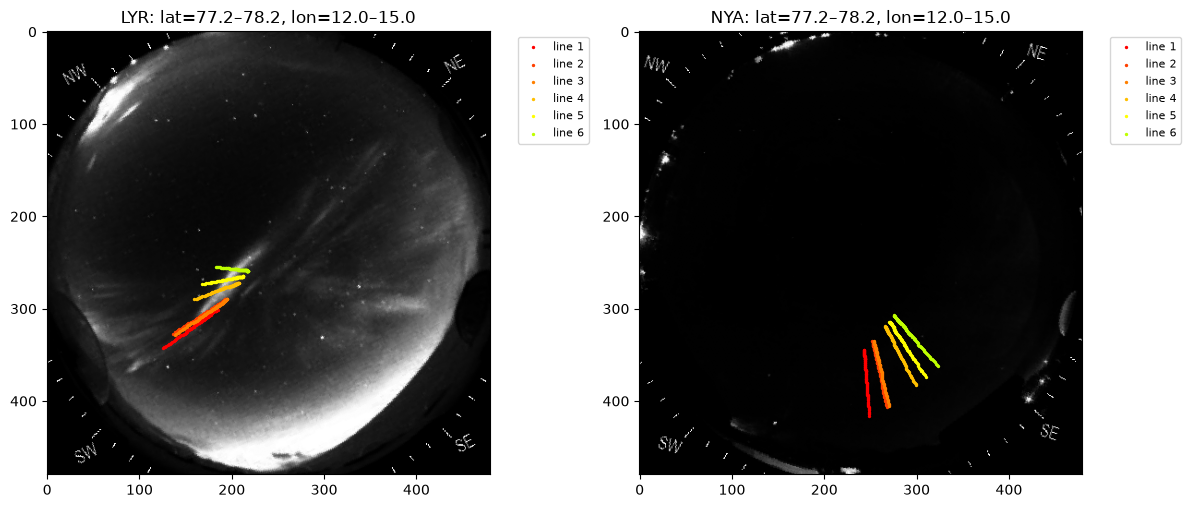

lat=77.2–78.2, lon=12.0–15.0 LYR:140.0, NYA:160.0
LYR  150.3 ± 12.2 km (std),  SEM 5.0 km
NYA  140.3 ± 25.6 km (std),  SEM 10.5 km
Both 145.3 ± 19.8 km (std),  SEM 5.7 km
Saved: out/out_fiedline_Guillaume_20200103085741/20200103085741_profiles_single.png


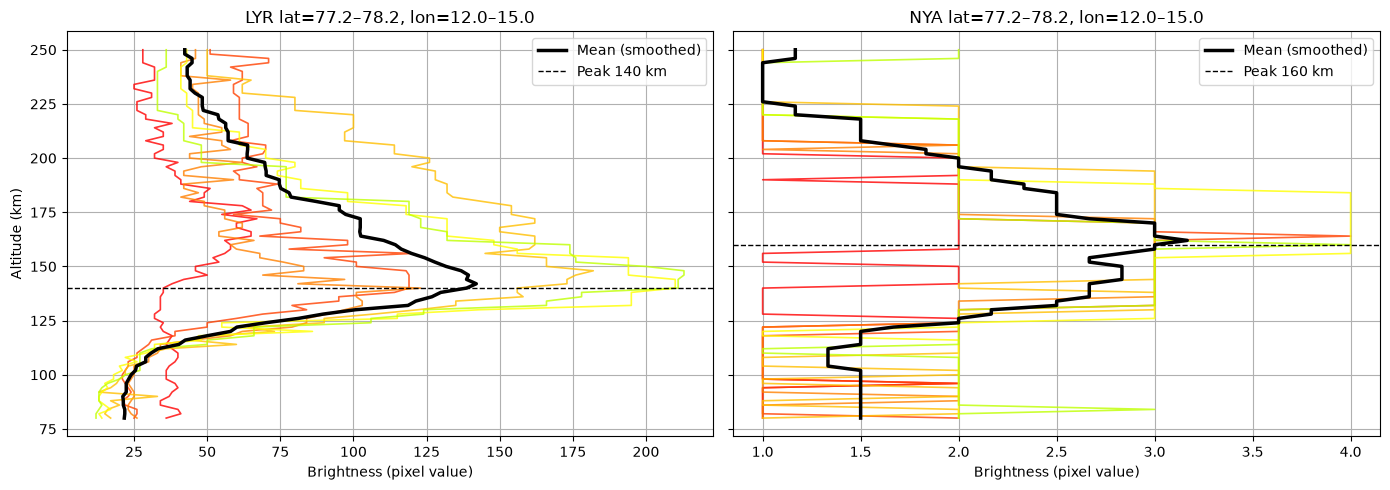

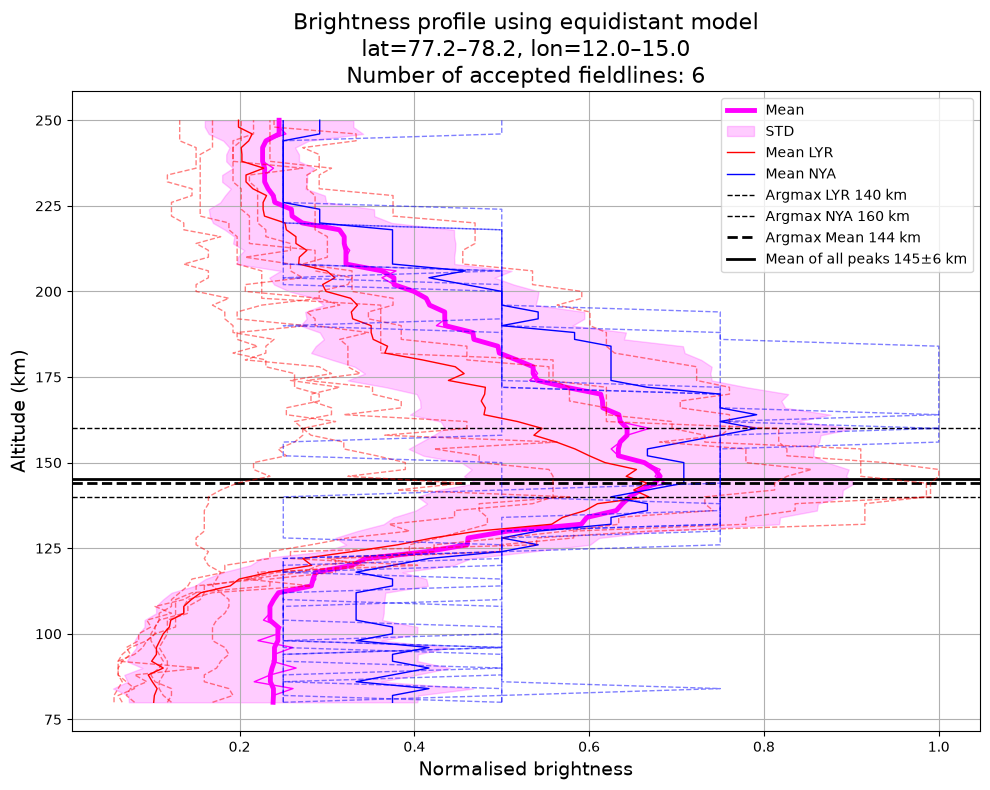

In [116]:
make_plots(all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA, lat_range, lon_range, save_prefix=date_time)